In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('retail.csv')
df.head()

,Order_ID,Customer_ID,Order_Date,Region,Product_Category,Customer_Segment,Quantity,Unit_Price,Discount_Rate,Revenue,Cost,Profit,Payment_Method
0,1,CUST3818,2024-08-18,North,Clothing,Corporate,5,300.68,0.27,1097.48,768.29,329.19,Credit Card
1,2,CUST9689,2024-06-19,South,Beauty,Home Office,9,32.89,0.02,290.09,179.33,110.76,Debit Card
2,3,CUST9147,2024-11-21,West,Sports,Corporate,5,345.61,0.25,1296.04,1022.60,273.44,Credit Card
3,4,CUST7938,2024-07-19,North,Clothing,Consumer,1,444.50,0.06,417.83,280.99,136.84,UPI
4,5,CUST5127,2024-10-28,South,Home & Kitchen,Consumer,5,65.13,0.21,257.26,151.90,105.36,Credit Card


EDA (Exploratory Data Analysis)

In [4]:
df.isnull().sum()

Order_ID            0
Customer_ID         0
Order_Date          0
Region              0
Product_Category    0
Customer_Segment    0
Quantity            0
Unit_Price          0
Discount_Rate       0
Revenue             0
Cost                0
Profit              0
Payment_Method      0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          10000 non-null  int64  
 1   Customer_ID       10000 non-null  object 
 2   Order_Date        10000 non-null  object 
 3   Region            10000 non-null  object 
 4   Product_Category  10000 non-null  object 
 5   Customer_Segment  10000 non-null  object 
 6   Quantity          10000 non-null  int64  
 7   Unit_Price        10000 non-null  float64
 8   Discount_Rate     10000 non-null  float64
 9   Revenue           10000 non-null  float64
 10  Cost              10000 non-null  float64
 11  Profit            10000 non-null  float64
 12  Payment_Method    10000 non-null  object 
dtypes: float64(5), int64(2), object(6)
memory usage: 1015.8+ KB


In [7]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Order_Date', 'Region', 'Product_Category',
       'Customer_Segment', 'Quantity', 'Unit_Price', 'Discount_Rate',
       'Revenue', 'Cost', 'Profit', 'Payment_Method'],
      dtype='object')

In [8]:
df['Order_date'] = pd.to_datetime(df['Order_Date'])

In [9]:
df['Order_month']= df['Order_date'].dt.month

In [10]:
df['Order_year']= df['Order_date'].dt.year

In [11]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Order_Date', 'Region', 'Product_Category',
       'Customer_Segment', 'Quantity', 'Unit_Price', 'Discount_Rate',
       'Revenue', 'Cost', 'Profit', 'Payment_Method', 'Order_date',
       'Order_month', 'Order_year'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          10000 non-null  int64         
 1   Customer_ID       10000 non-null  object        
 2   Order_Date        10000 non-null  object        
 3   Region            10000 non-null  object        
 4   Product_Category  10000 non-null  object        
 5   Customer_Segment  10000 non-null  object        
 6   Quantity          10000 non-null  int64         
 7   Unit_Price        10000 non-null  float64       
 8   Discount_Rate     10000 non-null  float64       
 9   Revenue           10000 non-null  float64       
 10  Cost              10000 non-null  float64       
 11  Profit            10000 non-null  float64       
 12  Payment_Method    10000 non-null  object        
 13  Order_date        10000 non-null  datetime64[ns]
 14  Order_month       10000

Text(0.5, 1.0, 'Revenue VS Region')

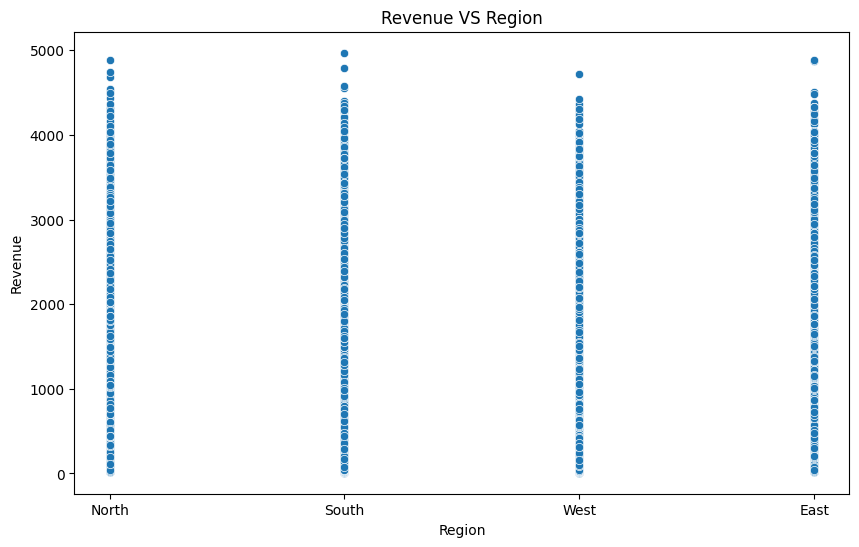

In [13]:
#Region vs Revenue
plt.figure(figsize=(10,6))
sns.scatterplot(x='Region', y='Revenue',data=df)
plt.title('Revenue VS Region')


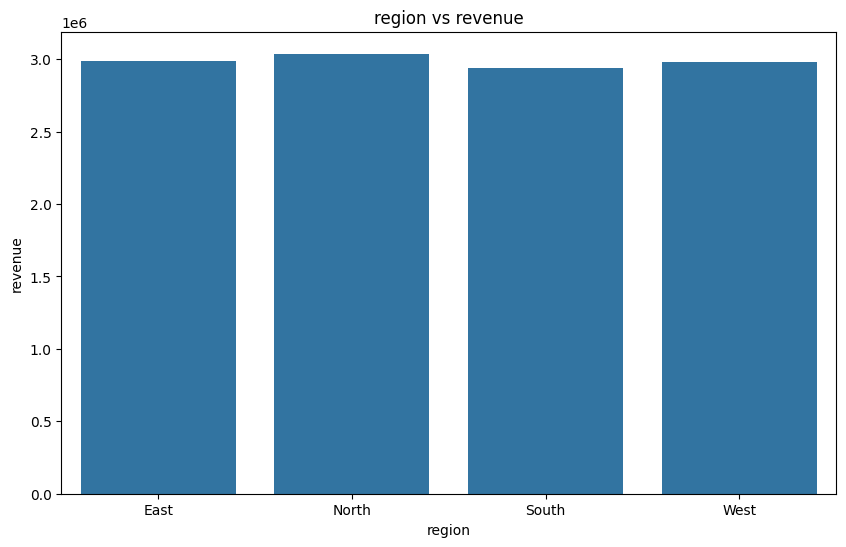

In [14]:
region_revenue = df.groupby('Region')['Revenue'].sum().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(x='Region', y='Revenue', data=region_revenue)
plt.title('region vs revenue')
plt.xlabel('region')
plt.ylabel('revenue')
plt.show()

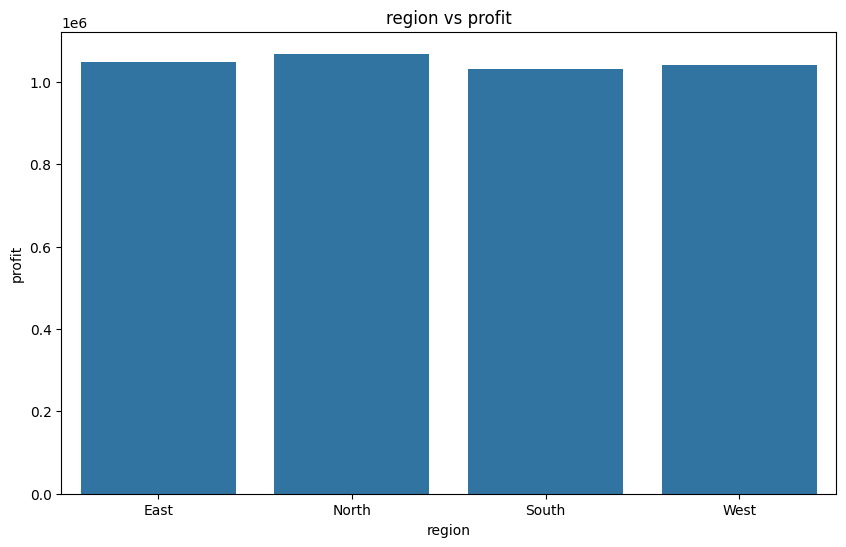

In [15]:
#region vs profit
region_profit = df.groupby('Region')['Profit'].sum().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(x='Region', y='Profit', data=region_profit)
plt.title('region vs profit')
plt.xlabel('region')
plt.ylabel('profit')
plt.show()

In [16]:
df.head()

,Order_ID,Customer_ID,Order_Date,Region,Product_Category,Customer_Segment,Quantity,Unit_Price,Discount_Rate,Revenue,Cost,Profit,Payment_Method,Order_date,Order_month,Order_year
0,1,CUST3818,2024-08-18,North,Clothing,Corporate,5,300.68,0.27,1097.48,768.29,329.19,Credit Card,2024-08-18,8,2024
1,2,CUST9689,2024-06-19,South,Beauty,Home Office,9,32.89,0.02,290.09,179.33,110.76,Debit Card,2024-06-19,6,2024
2,3,CUST9147,2024-11-21,West,Sports,Corporate,5,345.61,0.25,1296.04,1022.60,273.44,Credit Card,2024-11-21,11,2024
3,4,CUST7938,2024-07-19,North,Clothing,Consumer,1,444.50,0.06,417.83,280.99,136.84,UPI,2024-07-19,7,2024
4,5,CUST5127,2024-10-28,South,Home & Kitchen,Consumer,5,65.13,0.21,257.26,151.90,105.36,Credit Card,2024-10-28,10,2024


In [17]:
avg_profit = df['Profit'].mean()
print(avg_profit)

418.94976799999995


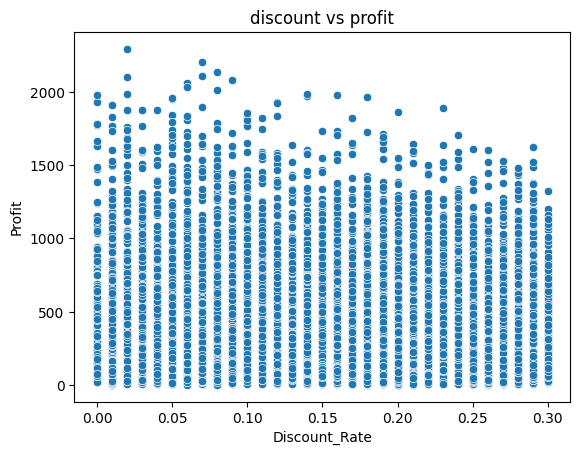

In [18]:
sns.scatterplot(x='Discount_Rate', y='Profit', data=df)
plt.title('discount vs profit')
plt.show()


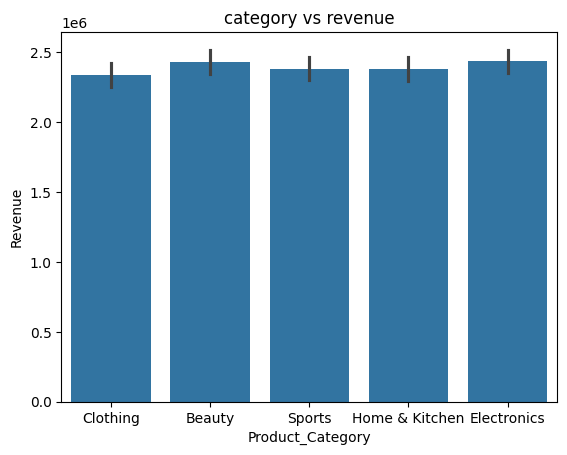

In [20]:
#Category vs revenue

sns.barplot(x='Product_Category', y='Revenue', data=df , estimator=sum)
plt.title('category vs revenue')
plt.show()

In [21]:
df.head()

,Order_ID,Customer_ID,Order_Date,Region,Product_Category,Customer_Segment,Quantity,Unit_Price,Discount_Rate,Revenue,Cost,Profit,Payment_Method,Order_date,Order_month,Order_year
0,1,CUST3818,2024-08-18,North,Clothing,Corporate,5,300.68,0.27,1097.48,768.29,329.19,Credit Card,2024-08-18,8,2024
1,2,CUST9689,2024-06-19,South,Beauty,Home Office,9,32.89,0.02,290.09,179.33,110.76,Debit Card,2024-06-19,6,2024
2,3,CUST9147,2024-11-21,West,Sports,Corporate,5,345.61,0.25,1296.04,1022.60,273.44,Credit Card,2024-11-21,11,2024
3,4,CUST7938,2024-07-19,North,Clothing,Consumer,1,444.50,0.06,417.83,280.99,136.84,UPI,2024-07-19,7,2024
4,5,CUST5127,2024-10-28,South,Home & Kitchen,Consumer,5,65.13,0.21,257.26,151.90,105.36,Credit Card,2024-10-28,10,2024


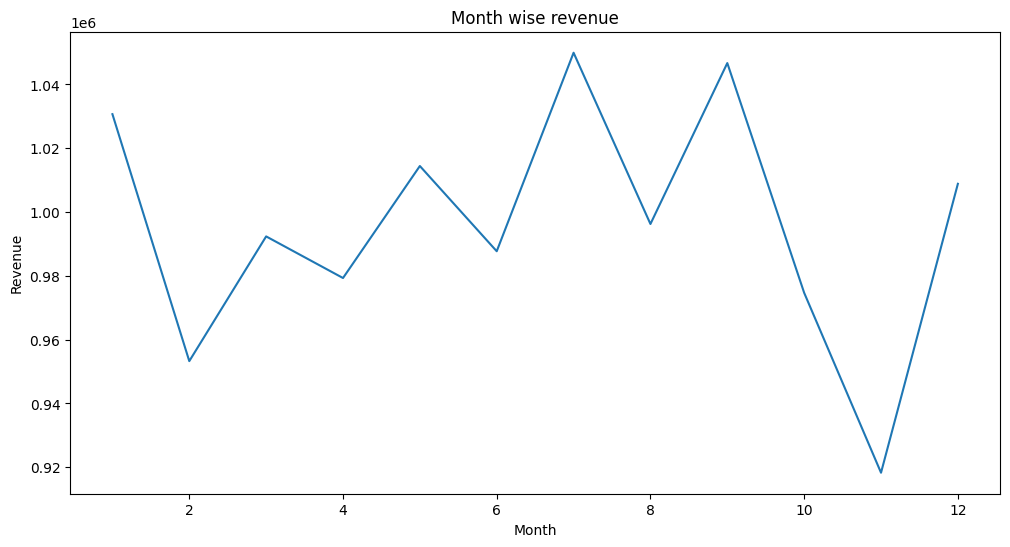

In [22]:
# Month wise revenue
 
Monthly_data = df.groupby('Order_month')['Revenue'].sum().reset_index()
plt.figure(figsize=(12,6))

sns.lineplot(x='Order_month' ,y='Revenue', data=Monthly_data)

plt.title('Month wise revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()


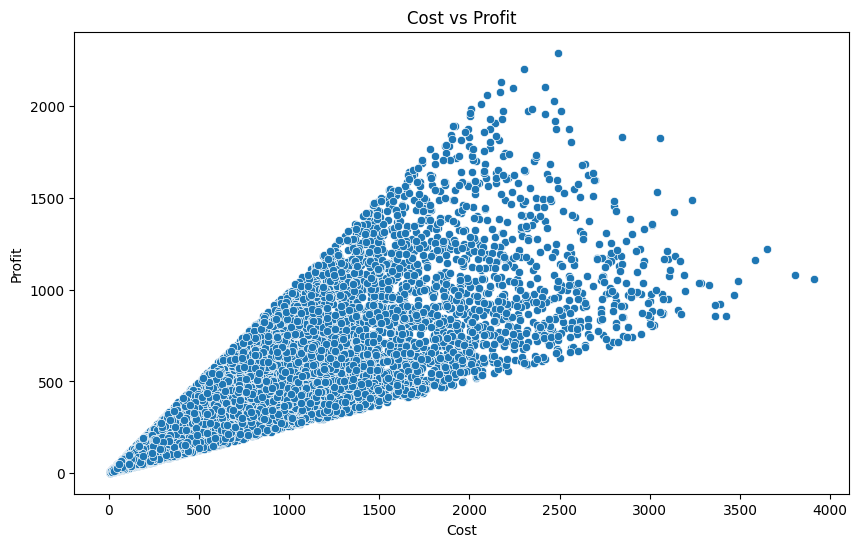

In [24]:
#Cost Vs Profit

plt.figure(figsize=(10,6))
sns.scatterplot(x='Cost', y='Profit', data=df)
plt.title('Cost vs Profit')
plt.xlabel('Cost')
plt.ylabel('Profit')
plt.show()

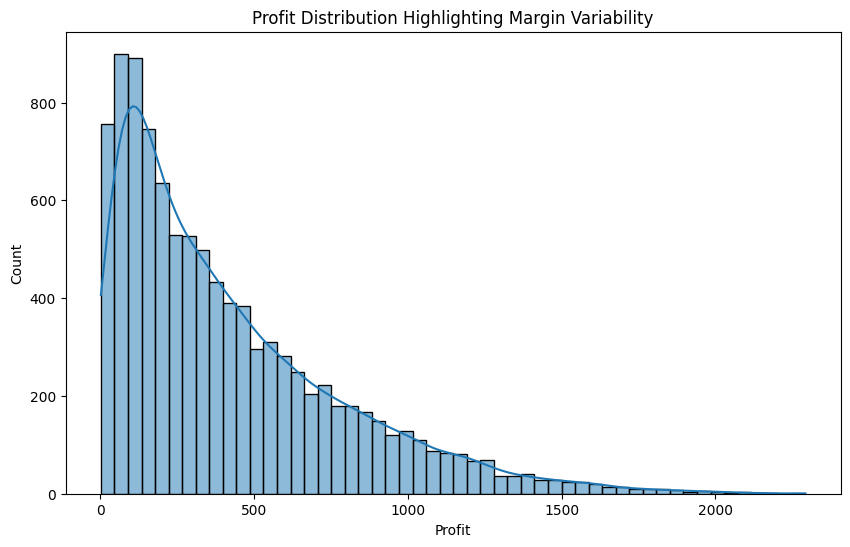

In [25]:
# Profit Distribution Hightlinghting Margin Varibility
plt.figure(figsize=(10,6))

sns.histplot(df['Profit'], kde=True)
plt.title('Profit Distribution Highlighting Margin Variability')
plt.show()


# Most sales give small profit,
# Very few sales give very high profit,
# Distribution is not normal, it is positively skewed.

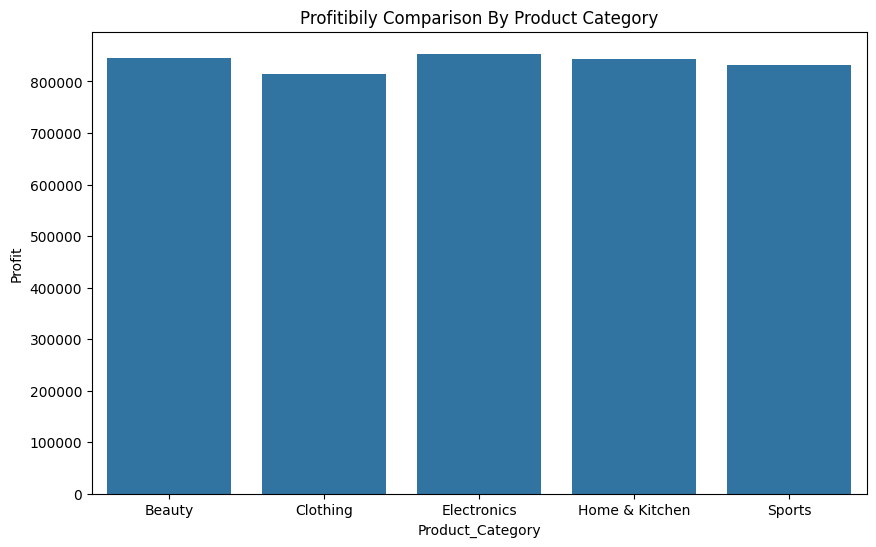

In [26]:
pro = df.groupby('Product_Category')['Profit'].sum().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(x='Product_Category',y='Profit',data=pro)
plt.title("Profitibily Comparison By Product Category")
plt.xlabel('Product_Category')
plt.ylabel('Profit')
plt.show()

# 1 Electronics has the highest profit
# 2 Clothing has the lowest profit
# 3 All categories are performing relatively close
# 4 Beauty, Home & Kitchen, and Sports are stable performers

In [31]:
df.head()

,Order_ID,Customer_ID,Order_Date,Region,Product_Category,Customer_Segment,Quantity,Unit_Price,Discount_Rate,Revenue,Cost,Profit,Payment_Method,Order_date,Order_month,Order_year
0,1,CUST3818,2024-08-18,North,Clothing,Corporate,5,300.68,0.27,1097.48,768.29,329.19,Credit Card,2024-08-18,8,2024
1,2,CUST9689,2024-06-19,South,Beauty,Home Office,9,32.89,0.02,290.09,179.33,110.76,Debit Card,2024-06-19,6,2024
2,3,CUST9147,2024-11-21,West,Sports,Corporate,5,345.61,0.25,1296.04,1022.60,273.44,Credit Card,2024-11-21,11,2024
3,4,CUST7938,2024-07-19,North,Clothing,Consumer,1,444.50,0.06,417.83,280.99,136.84,UPI,2024-07-19,7,2024
4,5,CUST5127,2024-10-28,South,Home & Kitchen,Consumer,5,65.13,0.21,257.26,151.90,105.36,Credit Card,2024-10-28,10,2024


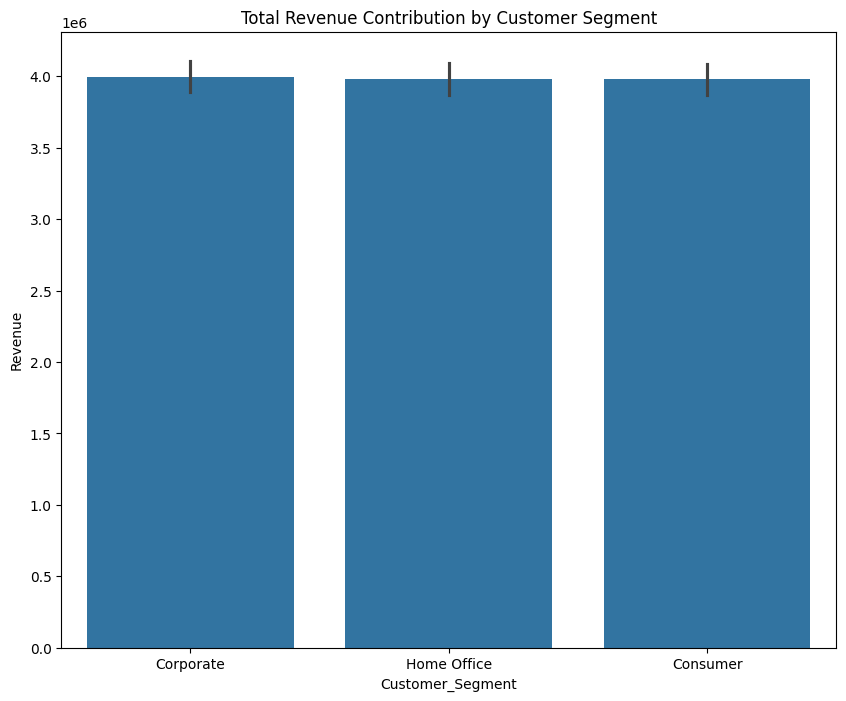

In [33]:
plt.figure(figsize=(10,8))
sns.barplot(x='Customer_Segment',y='Revenue', data =df , estimator=sum)
plt.title('Total Revenue Contribution by Customer Segment')
plt.show()

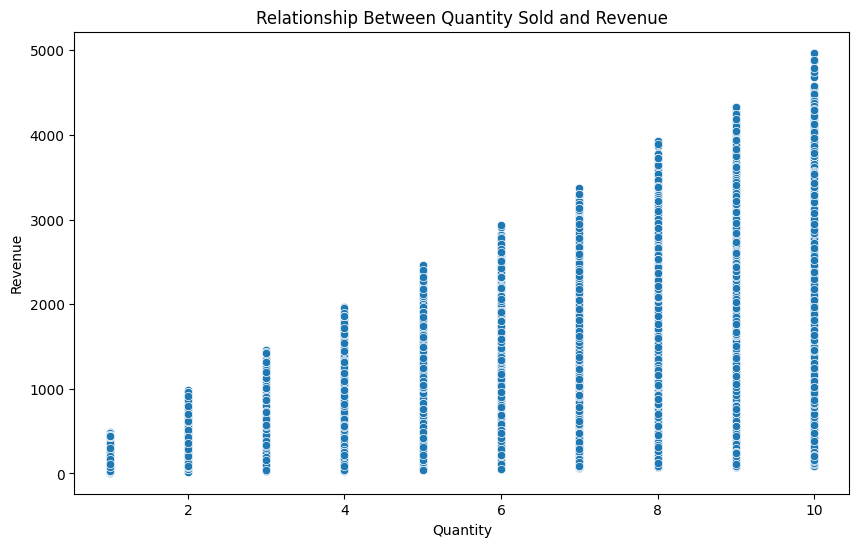

In [34]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Quantity',y='Revenue' , data=df)
plt.title('Relationship Between Quantity Sold and Revenue')
plt.show()

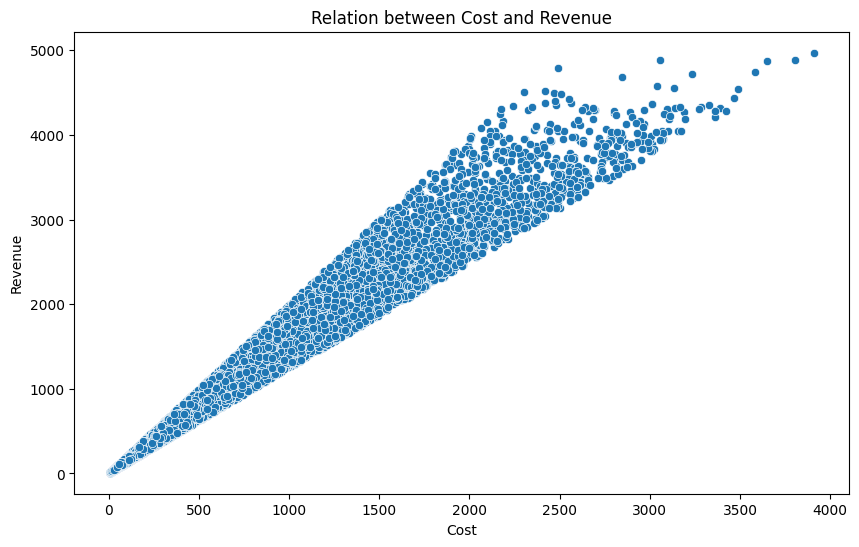

In [35]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Cost',y='Revenue',data=df)
plt.title('Relation between Cost and Revenue')
plt.show()


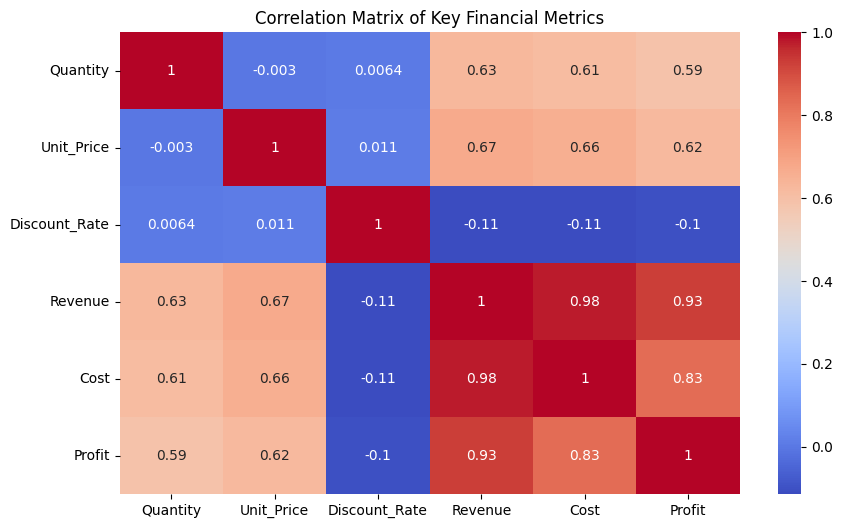

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['Quantity','Unit_Price','Discount_Rate','Revenue','Cost','Profit']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Key Financial Metrics')
plt.show()

# Revenue is the central driver.
# Profit is strongly dependent on Revenue.
# Discount strategy is not significantly impacting profit (based on this data).
# Increasing Quantity or Unit Price improves Revenue.